# Wine : statistiques descriptives et comparaison de méthodes de clustering

**Données.** 178 vins décrits par 13 mesures chimiques (`Alcohol`, `Malic_Acid`, `Ash`, ...). Il n'y a pas de
cible fournie : c'est un jeu de données pour de l'apprentissage **non supervisé** — on cherche à regrouper les
vins en fonction de leurs caractéristiques, sans savoir à l'avance combien de groupes il y a ni à quoi ils
correspondent.

**Objectif.** Comparer plusieurs méthodes de clustering (DBSCAN, K-Means, clustering hiérarchique, Gaussian
Mixture) sur ces données, et regarder laquelle capture le mieux la structure réelle du jeu de données.

Démarche : stats descriptives → préparation (standardisation, indispensable pour tout algorithme basé sur une
distance) → plusieurs méthodes de clustering, chacune expliquée pas à pas → comparaison de leurs performances.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (7, 4)

## 1. Chargement des données

In [2]:
dataset = pd.read_csv('wine-clustering.csv', sep=',')
print(dataset.shape)
dataset.head()

(178, 13)


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


## 2. Statistiques descriptives

Avant tout clustering, on regarde chaque variable individuellement : sa distribution, ses valeurs manquantes,
puis les relations entre variables.

### 2.1 Valeurs manquantes

In [4]:
dataset.isna().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

Aucune valeur manquante sur les 178 vins et 13 variables — pas de nettoyage nécessaire ici. Autre différence
avec un problème supervisé classique : toutes les colonnes sont numériques et il n'y a pas de variable cible.
On utilisera donc l'intégralité des 13 colonnes comme features pour le clustering.

### 2.2 Variables numériques

In [5]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic_Acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Ash_Alcanity,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Total_Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid_Phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
Color_Intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


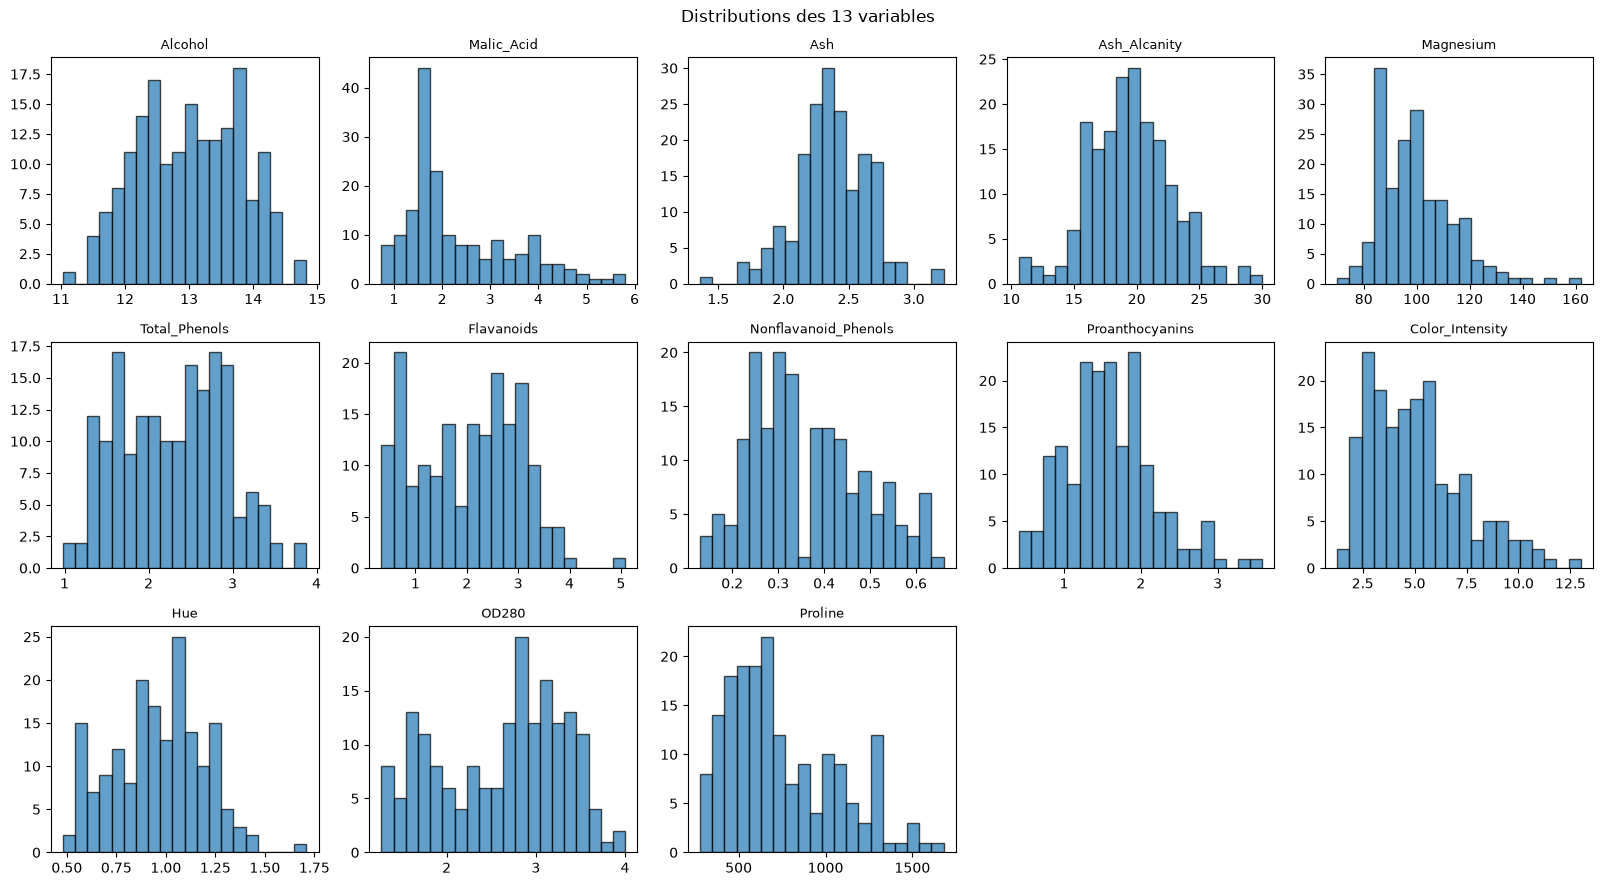

In [6]:
fig, axes = plt.subplots(3, 5, figsize=(16, 9))
for ax, col in zip(axes.flat, dataset.columns):
    ax.hist(dataset[col], bins=20, edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=9)
for ax in axes.flat[len(dataset.columns):]:
    ax.axis('off')
fig.suptitle('Distributions des 13 variables')
fig.tight_layout()
plt.show()

**Réflexion.** Les distributions sont globalement régulières, sans valeur aberrante flagrante. Mais les
échelles diffèrent énormément d'une variable à l'autre : `Proline` va jusqu'à ~1680, `Hue` reste sous 2. On le
quantifie ci-dessous.

### 2.3 Échelles très hétérogènes

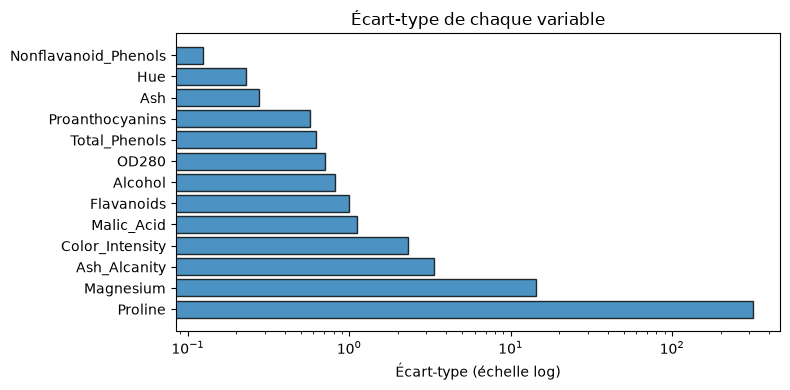

In [7]:
scale = dataset.std().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(scale.index, scale.values, edgecolor='black', alpha=0.8)
ax.set_xscale('log')
ax.set_xlabel('Écart-type (échelle log)')
ax.set_title("Écart-type de chaque variable")
fig.tight_layout()
plt.show()

**Réflexion.** L'écart-type de `Proline` (~315) est environ 1000 fois plus grand que celui de `Nonflavanoid_Phenols`
(~0.12). Un algorithme basé sur une distance (comme DBSCAN, qui utilise la distance euclidienne par défaut)
serait alors dominé presque entièrement par `Proline` : les autres variables compteraient pour presque rien dans
le calcul des distances, même si elles sont tout aussi informatives. **Il faudra standardiser toutes les
variables avant de faire du clustering** — c'est fait dans la section 3.

### 2.4 Corrélations entre variables

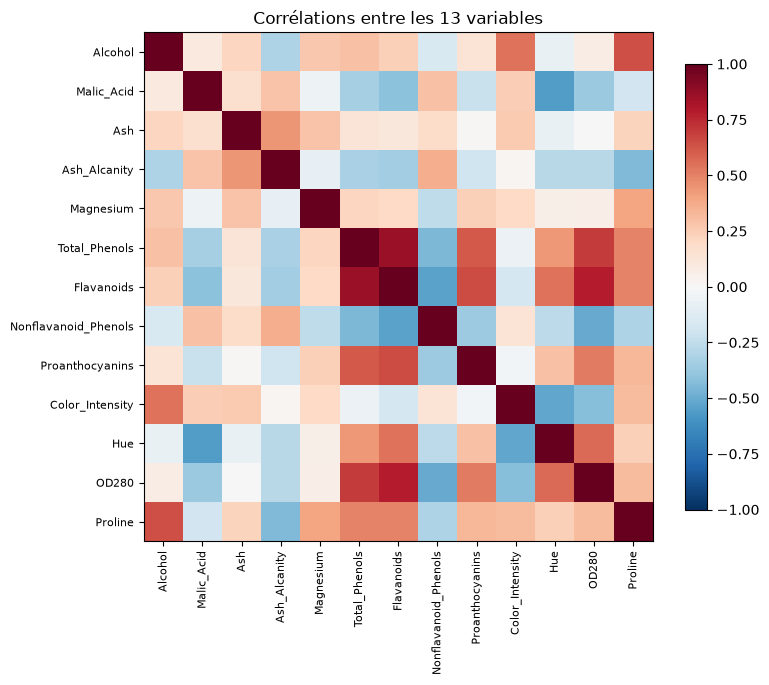

In [8]:
fig, ax = plt.subplots(figsize=(8, 7))
corr = dataset.corr()
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
fig.colorbar(im, shrink=0.8)
ax.set_title('Corrélations entre les 13 variables')
fig.tight_layout()
plt.show()

**Réflexion.** Certaines variables sont fortement corrélées entre elles (par exemple `Total_Phenols` et
`Flavanoids`, ou `Flavanoids` et `OD280`) : elles portent en partie une information redondante. Ce n'est pas un
problème pour DBSCAN en soi (contrairement à une régression linéaire), mais c'est utile à garder en tête pour
interpréter les clusters obtenus plus loin — plusieurs variables corrélées peuvent raconter la même histoire.

## 3. Préparation avant clustering

Pas de valeurs manquantes à traiter, pas de variable catégorielle à encoder, pas de cible à séparer (le
clustering est non supervisé). La seule étape nécessaire, vue en 2.3, est la **standardisation** : on centre et
on réduit chaque variable (moyenne 0, écart-type 1) pour qu'aucune ne domine artificiellement les distances.

In [9]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(dataset)
X_scaled = pd.DataFrame(X_scaled, columns=dataset.columns)
X_scaled.describe().T[['mean', 'std']]

,mean,std
Alcohol,-8.382808e-16,1.002821
Malic_Acid,-1.197544e-16,1.002821
Ash,-8.370333e-16,1.002821
Ash_Alcanity,-3.991813e-17,1.002821
Magnesium,-3.991813e-17,1.002821
Total_Phenols,0.000000e+00,1.002821
Flavanoids,-3.991813e-16,1.002821
Nonflavanoid_Phenols,3.592632e-16,1.002821
Proanthocyanins,-1.197544e-16,1.002821
Color_Intensity,2.494883e-17,1.002821


Toutes les moyennes sont maintenant proches de 0 et tous les écarts-types proches de 1 : les 13 variables ont
désormais le même poids potentiel dans le calcul des distances.

## 4. Comparaison de méthodes de clustering

On compare ici plusieurs familles d'algorithmes : DBSCAN (basé sur la densité), K-Means (basé sur les
centroïdes), le clustering hiérarchique, et un Gaussian Mixture (basé sur un modèle probabiliste). Chacun fait
des hypothèses différentes sur la forme des groupes qu'il cherche, ce qui explique en partie leurs résultats
très différents sur ce même jeu de données.

### 4.1 DBSCAN

Rappel des deux hyperparamètres de DBSCAN :
- **`eps`** : le rayon du voisinage autour de chaque point.
- **`min_samples`** : le nombre minimal de voisins (dans ce rayon) pour qu'un point soit considéré comme un
  point *dense* (cœur d'un cluster).

Particularité de DBSCAN par rapport aux autres méthodes comparées ici : il ne demande pas de fixer le nombre
de clusters à l'avance, il le déduit des données, et étiquette `-1` les points qu'il considère comme du bruit
(n'appartenant à aucun cluster dense).

#### Choisir `eps` : le graphique des k-distances

Technique classique : pour chaque point, on calcule la distance à son `k`-ième plus proche voisin (avec
`k = min_samples`), on trie ces distances, et on cherche un **coude** sur la courbe triée. Le coude sépare les
points « denses » (distance faible et stable) des points isolés (distance qui explose) — c'est une bonne
première estimation de `eps`.

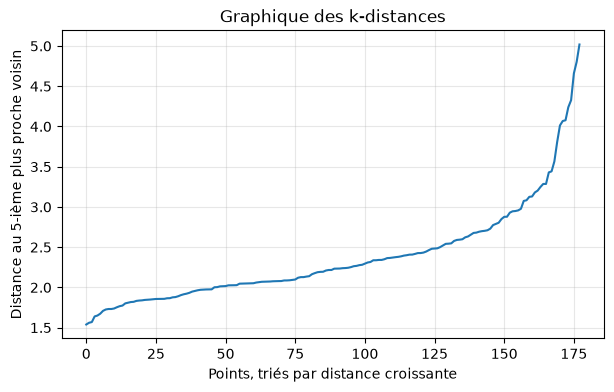

In [10]:
from sklearn.neighbors import NearestNeighbors

k = 5  # à faire varier en même temps que min_samples plus bas
neighbors = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(7, 4))
plt.plot(k_distances)
plt.xlabel("Points, triés par distance croissante")
plt.ylabel(f"Distance au {k}-ième plus proche voisin")
plt.title("Graphique des k-distances")
plt.grid(alpha=0.3)
plt.show()

Sur ce graphique (calculé avec `k = 5`), le coude se situe autour de `eps ≈ 2.7`. C'est une bonne première
estimation, mais elle ne suffit pas à elle seule : le résultat de DBSCAN dépend conjointement de `eps` **et**
de `min_samples`, et le coude change légèrement selon la valeur de `k` utilisée pour le tracer.

#### Affiner le choix avec une recherche sur grille

Une pratique courante consiste à tester systématiquement plusieurs couples `(eps, min_samples)` autour de
cette première estimation, et à comparer les résultats à l'aide du **score de silhouette**.

**Le score de silhouette, en détail.** Pour chaque point $i$, on calcule deux distances moyennes :
- $a(i)$ : la distance moyenne entre $i$ et les autres points **de son propre cluster** (cohésion — plus
  c'est petit, mieux $i$ est « chez lui »).
- $b(i)$ : la distance moyenne entre $i$ et les points du cluster voisin le plus proche, c'est-à-dire le
  meilleur « autre cluster » possible pour ce point (séparation — plus c'est grand, mieux $i$ est loin des
  autres groupes).

Le coefficient de silhouette du point est alors :

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

Il varie entre -1 et 1 :
- **proche de 1** : $i$ est bien plus proche de son propre cluster que du cluster voisin le plus proche →
  bonne assignation.
- **proche de 0** : $i$ est à peu près à égale distance des deux → il est sur la frontière entre deux
  clusters.
- **négatif** : $i$ est en moyenne plus proche du cluster voisin que du sien → il est probablement mal
  assigné.

Le « score de silhouette » d'un clustering complet (celui qu'on utilise partout dans ce notebook) est
simplement la **moyenne de $s(i)$ sur tous les points** (les points de bruit de DBSCAN, label `-1`, sont
exclus du calcul puisqu'ils n'appartiennent à aucun cluster). Contrairement à l'inertie utilisée dans la
méthode du coude, il ne favorise pas mécaniquement les grandes valeurs de *k* : ajouter un cluster inutile qui
coupe un groupe cohérent en deux fait baisser $b(i)$ sans raison, donc baisser la silhouette moyenne — c'est
ce qui en fait un bon signal pour choisir *k* ou comparer plusieurs clusterings entre eux.

On restreint la recherche sur grille aux couples qui donnent un nombre de clusters raisonnable (entre 2 et 5,
pour rester interprétable) et un taux de bruit inférieur à 50% (au-delà, le clustering perd de son sens).

In [11]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

candidates = []
for eps in np.arange(1.8, 4.2, 0.1):
    for ms in [4, 5, 6, 8, 10, 12, 15]:
        db_try = DBSCAN(eps=eps, min_samples=ms).fit(X_scaled)
        lab_try = db_try.labels_
        k_clusters = len(set(lab_try)) - (1 if -1 in lab_try else 0)
        k_noise = (lab_try == -1).sum()
        if 2 <= k_clusters <= 5 and k_noise < len(lab_try) * 0.5:
            mask = lab_try != -1
            sil = silhouette_score(X_scaled[mask], lab_try[mask])
            candidates.append((sil, round(eps, 2), ms, k_clusters, k_noise))

candidates.sort(reverse=True)
grid_results = pd.DataFrame(candidates[:10], columns=['silhouette', 'eps', 'min_samples', 'n_clusters', 'n_noise'])
grid_results

,silhouette,eps,min_samples,n_clusters,n_noise
0,0.409094,2.3,12,3,78
1,0.396992,2.4,15,2,80
2,0.364113,2.3,10,2,64
3,0.353135,2.4,12,2,58
4,0.350464,2.2,8,2,67
5,0.350215,2.2,6,2,58
6,0.348012,2.2,5,2,55
7,0.342166,2.3,8,2,52
8,0.341905,2.5,15,2,51
9,0.340093,2.2,4,2,48


#### Résultat de la recherche

Le tableau ci-dessus liste les 10 meilleurs couples `(eps, min_samples)` trouvés, triés par score de
silhouette décroissant. Le meilleur compromis obtenu est `eps = 2.3` et `min_samples = 12`, avec un score de
silhouette d'environ 0.41 — nettement plus élevé que les autres candidats proches du coude initial (`eps ≈ 2.7`
sans affinage donnait un score plus faible). C'est cette configuration qui est utilisée ci-dessous.

In [12]:
eps = 2.3          # retenu par la recherche sur grille ci-dessus
min_samples = 12   # retenu par la recherche sur grille ci-dessus

db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
labels = db.labels_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"Clusters trouvés : {n_clusters}")
print(f"Points classés comme bruit : {n_noise} / {len(labels)}")

Clusters trouvés : 3
Points classés comme bruit : 78 / 178


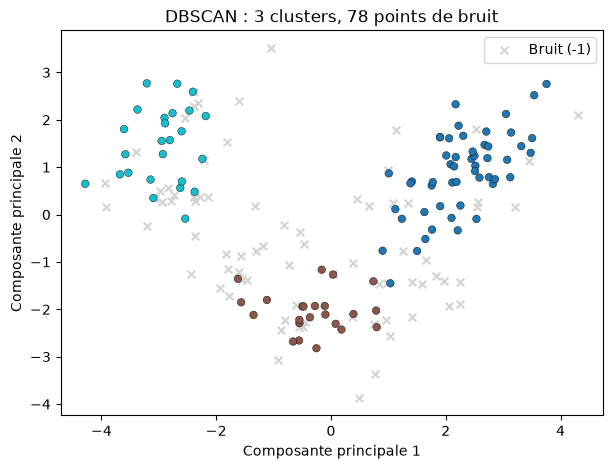

In [13]:
from sklearn.decomposition import PCA

X_2d = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

is_noise = labels == -1

plt.figure(figsize=(7, 5))
# bruit : gris, marqueur "x", en dessous
plt.scatter(X_2d[is_noise, 0], X_2d[is_noise, 1], c='lightgray', marker='x', s=30, label='Bruit (-1)')
# vrais clusters : une couleur par cluster, par-dessus
plt.scatter(X_2d[~is_noise, 0], X_2d[~is_noise, 1], c=labels[~is_noise], cmap='tab10',
            s=30, edgecolor='k', linewidth=0.3)
plt.title(f"DBSCAN : {n_clusters} clusters, {n_noise} points de bruit")
plt.xlabel('Composante principale 1'); plt.ylabel('Composante principale 2')
plt.legend()
plt.show()

**Interprétation.** Avec `eps = 2.3` et `min_samples = 12`, DBSCAN trouve **3 clusters**, avec **78 des 178
vins (44%) classés comme bruit**.

Deux lectures possibles :
- Le nombre de clusters (3) est cohérent avec un fait externe à ce fichier : la version originale de ce jeu de
  données (le dataset "Wine" de l'UCI) provient de **3 cépages différents**, non fournis ici. Retrouver 3
  groupes sans aucune étiquette est donc un bon signe.
- Le taux de bruit élevé (44%) montre une limite connue de DBSCAN : avec une seule paire `(eps, min_samples)`
  globale, il suppose une densité à peu près homogène dans tout l'espace. Si les 3 groupes de vins ont des
  densités différentes (un cépage plus "compact" chimiquement qu'un autre), DBSCAN a tendance à bien capturer
  le groupe le plus dense et à rejeter une partie des points des groupes plus diffus comme du bruit plutôt que
  de les assigner au mauvais cluster. C'est le compromis qu'on observe dans le tableau de la recherche sur
  grille : des `eps` plus petits (par exemple `eps = 2.1, min_samples = 6`) donnent moins de bruit (70 points)
  mais une séparation moins nette entre clusters (silhouette ≈ 0.23, contre 0.41 ici).

On regarde maintenant comment se comportent d'autres méthodes de clustering sur ce même jeu de données.

### 4.2 Estimer `k` pour les méthodes qui en ont besoin

K-Means, le clustering hiérarchique et le Gaussian Mixture, contrairement à DBSCAN, demandent de fixer à
l'avance le nombre de clusters *k*. Cela ne veut pas dire qu'il faut le deviner à l'aveugle : deux techniques
classiques permettent de l'estimer à partir des données seules, sans aucune connaissance préalable :

- **La méthode du coude** : on trace l'inertie (somme des distances au carré entre chaque point et le centre
  de son cluster) en fonction de *k*. Elle diminue toujours quand *k* augmente, mais souvent avec un coude net
  au-delà duquel ajouter des clusters n'apporte plus grand-chose.
- **Le score de silhouette** : contrairement à l'inertie, il ne diminue pas mécaniquement avec *k* — il
  atteint un maximum pour la valeur de *k* qui sépare le mieux les groupes. C'est souvent le signal le plus
  fiable des deux.

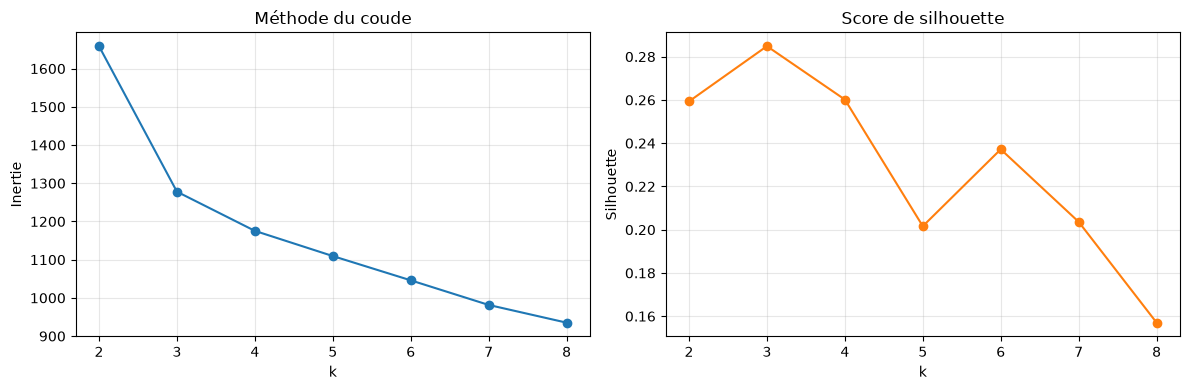

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias, silhouettes = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertie'); axes[0].set_title('Méthode du coude')
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), silhouettes, marker='o', color='tab:orange')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].set_title('Score de silhouette')
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

**Réflexion.** Les deux courbes pointent vers **k = 3**, de façon indépendante : le coude de l'inertie est net
entre k=2 et k=3 (la baisse ralentit fortement ensuite), et la silhouette atteint son maximum exactement à
k=3. On retient donc k=3 pour les méthodes suivantes.

*(À titre de comparaison seulement : le critère BIC d'un modèle de mélange gaussien, une troisième méthode
d'estimation de *k*, est ici minimal à k=2, pas k=3 — un rappel que BIC/AIC ne sont pas toujours fiables sur de
petits échantillons en haute dimension, et qu'il vaut mieux croiser plusieurs méthodes plutôt que suivre une
seule.)*

### 4.3 K-Means

K-Means (k=3)  silhouette = 0.285
DBSCAN (eps=2.3, min_samples=12, bruit exclu)  silhouette = 0.409


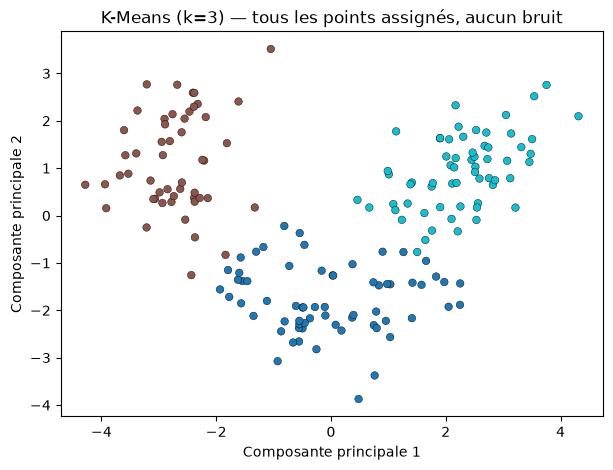

In [15]:
km3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_scaled)
labels_km = km3.labels_

sil_km = silhouette_score(X_scaled, labels_km)
print(f"K-Means (k=3)  silhouette = {sil_km:.3f}")
print(f"DBSCAN (eps=2.3, min_samples=12, bruit exclu)  silhouette = {silhouette_score(X_scaled[labels != -1], labels[labels != -1]):.3f}")

X_2d_km = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
plt.figure(figsize=(7, 5))
plt.scatter(X_2d_km[:, 0], X_2d_km[:, 1], c=labels_km, cmap='tab10', s=30, edgecolor='k', linewidth=0.3)
plt.title("K-Means (k=3) — tous les points assignés, aucun bruit")
plt.xlabel('Composante principale 1'); plt.ylabel('Composante principale 2')
plt.show()

**Réflexion.** La silhouette de K-Means (k=3) est *plus basse* que celle de DBSCAN calculée sur ses seuls
points non-bruit (~0.29 contre ~0.41). C'est trompeur : la silhouette de DBSCAN est gonflée artificiellement
parce qu'il a le luxe d'ignorer 78 points ambigus (44% du jeu de données) que K-Means, lui, doit
obligatoirement assigner quelque part. Pour comparer les méthodes sur un pied d'égalité, il faut un critère
qui ne se laisse pas berner par ce genre d'esquive — c'est l'objet de la section suivante.

### 4.4 Autres méthodes et comparaison avec la vérité terrain

On ajoute deux méthodes supplémentaires à la comparaison : le **clustering hiérarchique** (agglomératif,
linkage de Ward) et un **Gaussian Mixture** (qui, contrairement à K-Means, autorise des clusters de forme
elliptique plutôt que purement sphérique).

Ce fichier `wine-clustering.csv` ne contient pas d'étiquette — c'est voulu, pour un exercice de clustering non
supervisé. Mais ses 178 lignes et 13 colonnes correspondent exactement (valeur pour valeur) au jeu de données
« Wine » classique de l'UCI, disponible via `sklearn.datasets.load_wine()`, qui lui *inclut* l'information
d'origine : le cépage réel de chaque vin (3 cépages, non communiqués dans notre CSV). On l'utilise ici
uniquement pour **vérifier après coup** la qualité des 4 clusterings — dans un vrai problème non supervisé,
cette vérité terrain ne serait pas disponible, mais elle permet ici de comparer objectivement les méthodes
plutôt que de se fier à la silhouette seule.

In [16]:
from sklearn.datasets import load_wine
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

wine_full = load_wine()
y_true = wine_full.target  # cépage réel, absent de notre CSV, utilisé ici uniquement pour validation

assert np.allclose(wine_full.data[:, 0], dataset['Alcohol'].values)  # confirme l'alignement ligne à ligne

ag = AgglomerativeClustering(n_clusters=3, linkage='ward').fit(X_scaled)
gm = GaussianMixture(n_components=3, random_state=42).fit(X_scaled).predict(X_scaled)

def summarize(name, lab):
    n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
    ari = adjusted_rand_score(y_true, lab)
    nmi = normalized_mutual_info_score(y_true, lab)
    return [name, n_clusters, round(ari, 3), round(nmi, 3)]

comparison = pd.DataFrame(
    [
        summarize('DBSCAN (eps=2.3, min_samples=12)', labels),
        summarize('K-Means (k=3)', labels_km),
        summarize('Agglomératif Ward (k=3)', ag.labels_),
        summarize('Gaussian Mixture (k=3)', gm),
    ],
    columns=['Méthode', 'n_clusters', 'ARI', 'NMI'],
).set_index('Méthode')
comparison

,n_clusters,ARI,NMI
Méthode,,,
"DBSCAN (eps=2.3, min_samples=12)",3,0.407,0.518
K-Means (k=3),3,0.897,0.876
Agglomératif Ward (k=3),3,0.790,0.786
Gaussian Mixture (k=3),3,0.897,0.876


### 4.5 Conclusion : quelle méthode retenir ?

L'ARI (*Adjusted Rand Index*, 1 = partition identique aux vrais cépages, 0 = pas mieux que le hasard) permet
de départager objectivement les 4 méthodes comparées :

| Méthode | n_clusters | ARI | NMI |
|---|---|---|---|
| DBSCAN (eps=2.3, min_samples=12) | 3 | 0.407 | 0.518 |
| **K-Means (k=3)** | 3 | **0.897** | 0.876 |
| Agglomératif Ward (k=3) | 3 | 0.790 | 0.786 |
| **Gaussian Mixture (k=3)** | 3 | **0.897** | 0.876 |

**K-Means et Gaussian Mixture arrivent nettement en tête** (ARI ≈ 0.90), sans écarter aucun vin. Le
clustering hiérarchique fait un peu moins bien (0.79). **DBSCAN est la méthode la moins adaptée ici** (0.41),
malgré sa silhouette flatteuse obtenue en excluant 44% des points.

Ce résultat s'explique par les hypothèses de chaque méthode : DBSCAN cherche des clusters denses, de forme
arbitraire, séparés par de vraies zones de bruit. Ici, les 3 cépages forment au contraire des groupes
convexes, à peu près sphériques et de densité similaire — exactement le cas où K-Means et le Gaussian Mixture
excellent. Il n'y a pas non plus de vrais outliers dans ces données : les 78 vins que DBSCAN écarte comme
« bruit » sont en réalité des cas limites entre deux cépages chimiquement proches, pas des anomalies.

**Ce que montre cette comparaison, en général :**
- **K-Means / Gaussian Mixture** : à privilégier pour des clusters compacts, en nombre estimable (coude,
  silhouette, ou connaissance du domaine) — c'est le cas de la majorité des jeux de données, et c'était le cas
  ici.
- **Clustering hiérarchique** : une alternative flexible qui ne demande pas non plus de fixer *k* a priori
  pour l'explorer (via le dendrogramme), utile quand on veut visualiser plusieurs granularités de
  regroupement.
- **DBSCAN** : préférable quand le nombre de clusters est vraiment impossible à estimer autrement, quand les
  clusters ont une forme non convexe, ou surtout quand il existe de vrais points aberrants à isoler
  explicitement (détection d'anomalies, données géospatiales, densités très hétérogènes) — un scénario
  différent de celui de ce jeu de données.
- **Approche hybride** : si *k* est réellement inconnu et inestimable autrement, DBSCAN peut servir
  d'éclaireur (juste pour estimer un nombre de clusters plausible), puis K-Means prend le relai pour
  l'assignation finale.